# Notebook 05 — Reporting Layer & Executive Summary

This notebook produces **stakeholder-ready outputs** from the optimisation layer:

- Reads optimisation exports from **Notebook 04** (`reports/*.csv`)
- Builds **scenario comparison tables**
- Produces **publication-grade plots**
- Writes:
  - `reports/tables/scenario_summary_notebook05.csv`
  - `reports/tables/shortlists_notebook05.csv`
  - `reports/tables/squad_summary_notebook05.csv`
  - `reports/figures/*.png`

If you have not run Notebook 04 yet, run it first to generate the exports.

## 0) Imports & Paths

In [13]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

def find_db_path(db_name: str = "scouting.duckdb") -> Path:
    """Find db/scouting.duckdb robustly regardless of notebook working directory."""
    cwd = Path.cwd()
    candidates = [cwd / "db" / db_name] + [p / "db" / db_name for p in cwd.parents]
    for c in candidates:
        if c.exists():
            return c
    tried = "\n  - ".join(str(p) for p in candidates)
    raise FileNotFoundError(
        f"DuckDB file not found. Tried:\n  - {tried}\n\n"
        "Fix: ensure the repository contains 'db/scouting.duckdb'."
    )

DB_PATH = find_db_path()

REPORTS_DIR = Path("reports")
FIG_DIR = REPORTS_DIR / "figures"
TABLE_DIR = REPORTS_DIR / "tables"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Using DB_PATH:", DB_PATH)
print("Reports dir:", REPORTS_DIR.resolve())

Using DB_PATH: c:\Users\manue\Projects\risk-adjusted-scouting\db\scouting.duckdb
Reports dir: C:\Users\manue\Projects\risk-adjusted-scouting\notebooks\reports


## 1) Helpers (I/O + lightweight profiling)

In [14]:
def safe_read_csv(path: Path) -> Optional[pd.DataFrame]:
    if not path.exists():
        print(f"[WARN] Missing: {path}")
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[WARN] Failed to read {path}: {e}")
        return None

def connect_duckdb(db_path: Path = DB_PATH) -> duckdb.DuckDBPyConnection:
    if not db_path.exists():
        raise FileNotFoundError(f"DuckDB file not found at: {db_path}")
    return duckdb.connect(str(db_path), read_only=True)

def table_exists(con: duckdb.DuckDBPyConnection, table_name: str) -> bool:
    q = '''SELECT COUNT(*) AS n
           FROM information_schema.tables
           WHERE table_schema = 'main' AND table_name = ?'''
    n = con.execute(q, [table_name]).fetchone()[0]
    return int(n) > 0

def summarise_squad(df: Optional[pd.DataFrame], label: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame([{
            "label": label, "n": 0, "avg_age": np.nan, "sum_talent": np.nan, "sum_risk": np.nan,
            "sum_cost_eurm": np.nan, "sum_tco_eurm": np.nan
        }])

    out: Dict[str, object] = {
        "label": label,
        "n": int(len(df)),
        "avg_age": float(pd.to_numeric(df.get("age"), errors="coerce").mean()) if "age" in df.columns else np.nan,
        "sum_talent": float(pd.to_numeric(df.get("talent"), errors="coerce").sum()) if "talent" in df.columns else np.nan,
        "sum_risk": float(pd.to_numeric(df.get("risk_score", df.get("risk")), errors="coerce").sum())
                    if ("risk_score" in df.columns or "risk" in df.columns) else np.nan,
        "sum_cost_eurm": float(pd.to_numeric(df.get("cost_eurm"), errors="coerce").sum()) if "cost_eurm" in df.columns else np.nan,
        "sum_tco_eurm": float(pd.to_numeric(df.get("tco_eurm"), errors="coerce").sum()) if "tco_eurm" in df.columns else np.nan,
    }

    if "pos_group" in df.columns:
        vc = df["pos_group"].value_counts().to_dict()
        for k, v in vc.items():
            out[f"count_{k}"] = int(v)

    return pd.DataFrame([out])

## 2) Load Notebook 04 Exports

Expected files from Notebook 04:
- `reports/scenario_report_notebook04.csv`
- `reports/squad_<scenario>.csv` for each scenario
- `reports/full_squad_18.csv`
- `reports/full_squad_23.csv`

In [15]:
scenario_report = safe_read_csv(REPORTS_DIR / "scenario_report_notebook04.csv")
scenario_report

,scenario,success,message,k,budget_tco,lambda,objective,total_tco,total_talent,total_risk
0,baseline,True,Optimal solution found.,3,250.0,0.5,9.811523,239.491044,8.785608,-2.051830
1,loose_budget,True,Optimal solution found.,3,400.0,0.5,10.876748,314.331995,9.559437,-2.634622
2,risk_averse,True,Optimal solution found.,3,250.0,1.5,12.929653,221.529216,7.484595,-3.630038
3,tight_budget,True,Optimal solution found.,3,150.0,0.5,8.778524,138.455760,7.274233,-3.008582


In [16]:
scenario_squads = {}
if scenario_report is not None and "scenario" in scenario_report.columns:
    for sc in scenario_report["scenario"].astype(str).unique().tolist():
        scenario_squads[sc] = safe_read_csv(REPORTS_DIR / f"squad_{sc}.csv")

print("Loaded scenario squads:", list(scenario_squads.keys()))

Loaded scenario squads: ['baseline', 'loose_budget', 'risk_averse', 'tight_budget']


In [17]:
squad18 = safe_read_csv(REPORTS_DIR / "full_squad_18.csv")
squad23 = safe_read_csv(REPORTS_DIR / "full_squad_23.csv")

print("18-man:", None if squad18 is None else squad18.shape)
print("23-man:", None if squad23 is None else squad23.shape)

18-man: (18, 12)
23-man: (23, 12)


## 3) Executive Scenario Table (K-signings)

Exports:
- `reports/tables/scenario_summary_notebook05.csv`

In [18]:
if scenario_report is None or scenario_report.empty:
    raise RuntimeError("scenario_report_notebook04.csv not found or empty. Run Notebook 04 first.")

keep = [c for c in [
    "scenario", "success", "k", "budget_tco", "lambda", "objective",
    "total_tco", "total_talent", "total_risk", "message"
] if c in scenario_report.columns]

scenario_summary = scenario_report[keep].copy()

for c in ["budget_tco", "objective", "total_tco", "total_talent", "total_risk"]:
    if c in scenario_summary.columns:
        scenario_summary[c] = pd.to_numeric(scenario_summary[c], errors="coerce")

scenario_summary = scenario_summary.sort_values(["scenario"]).reset_index(drop=True)

out_csv = TABLE_DIR / "scenario_summary_notebook05.csv"
scenario_summary.to_csv(out_csv, index=False)
print("Wrote:", out_csv)
scenario_summary

Wrote: reports\tables\scenario_summary_notebook05.csv


,scenario,success,k,budget_tco,lambda,objective,total_tco,total_talent,total_risk,message
0,baseline,True,3,250.0,0.5,9.811523,239.491044,8.785608,-2.051830,Optimal solution found.
1,loose_budget,True,3,400.0,0.5,10.876748,314.331995,9.559437,-2.634622,Optimal solution found.
2,risk_averse,True,3,250.0,1.5,12.929653,221.529216,7.484595,-3.630038,Optimal solution found.
3,tight_budget,True,3,150.0,0.5,8.778524,138.455760,7.274233,-3.008582,Optimal solution found.


## 4) Scenario Shortlists (Top picks per scenario)

Exports:
- `reports/tables/shortlists_notebook05.csv`

In [19]:
rows = []
for sc, df in scenario_squads.items():
    if df is None or df.empty:
        continue

    name_col = "player_name" if "player_name" in df.columns else ("player" if "player" in df.columns else None)
    talent_col = "talent" if "talent" in df.columns else ("talent_score" if "talent_score" in df.columns else None)
    if talent_col is None:
        continue

    d2 = df.copy()
    d2[talent_col] = pd.to_numeric(d2[talent_col], errors="coerce")
    d2 = d2.sort_values(talent_col, ascending=False).head(10)

    for _, r in d2.iterrows():
        rows.append({
            "scenario": sc,
            "player_id": r.get("player_id", np.nan),
            "player_name": r.get(name_col, np.nan) if name_col else np.nan,
            "position": r.get("position", r.get("pos_group", np.nan)),
            "age": r.get("age", np.nan),
            "talent": r.get(talent_col, np.nan),
            "risk": r.get("risk", r.get("risk_score", np.nan)),
            "cost_eurm": r.get("cost_eurm", np.nan),
            "tco_eurm": r.get("tco_eurm", np.nan),
        })

shortlists = pd.DataFrame(rows)
out_csv = TABLE_DIR / "shortlists_notebook05.csv"
shortlists.to_csv(out_csv, index=False)
print("Wrote:", out_csv)
shortlists.head(15)

Wrote: reports\tables\shortlists_notebook05.csv


,scenario,player_id,player_name,position,age,talent,risk,cost_eurm,tco_eurm
0,baseline,568177,Cole Palmer,Midfield,21.0,3.407091,-0.268297,80.0,119.745522
1,baseline,315779,Christian Pulisic,Attack,24.0,3.160788,-1.219410,40.0,59.872761
2,baseline,548111,Alex Baena,Midfield,22.0,2.217729,-0.564123,40.0,59.872761
3,loose_budget,568177,Cole Palmer,Midfield,21.0,3.407091,-0.268297,80.0,119.745522
4,loose_budget,315779,Christian Pulisic,Attack,24.0,3.160788,-1.219410,40.0,59.872761
5,loose_budget,357164,Rafael Leão,Attack,24.0,2.991558,-1.146915,90.0,134.713712
6,risk_averse,315779,Christian Pulisic,Attack,24.0,3.160788,-1.219410,40.0,59.872761
7,risk_averse,357164,Rafael Leão,Attack,24.0,2.991558,-1.146915,90.0,134.713712
8,risk_averse,392959,Andrea Colpani,Midfield,24.0,1.332250,-1.263713,18.0,26.942742
9,tight_budget,315779,Christian Pulisic,Attack,24.0,3.160788,-1.219410,40.0,59.872761


## 5) Visuals — Scenario Comparison

Saved into `reports/figures/`.

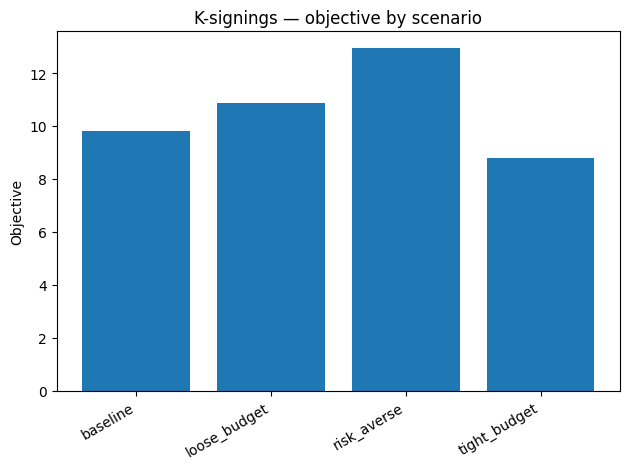

Saved: reports\figures\k_signings_objective_by_scenario.png


In [20]:
plt.figure()
plt.bar(scenario_summary["scenario"].astype(str), scenario_summary["objective"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Objective")
plt.title("K-signings — objective by scenario")
plt.tight_layout()
fig1 = FIG_DIR / "k_signings_objective_by_scenario.png"
plt.savefig(fig1, dpi=200)
plt.show()
print("Saved:", fig1)

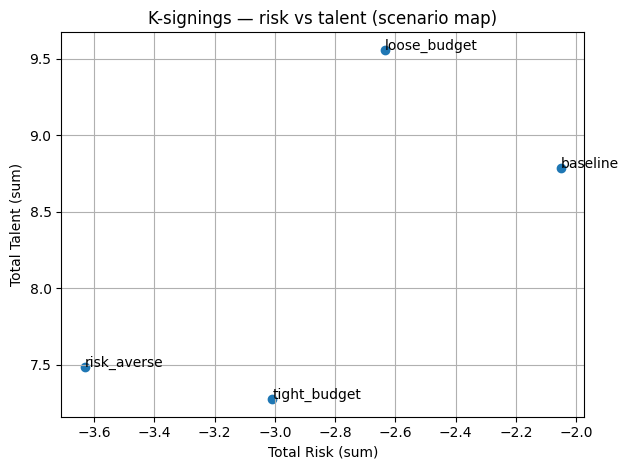

Saved: reports\figures\k_signings_risk_talent_scenarios.png


In [21]:
plt.figure()
plt.scatter(scenario_summary["total_risk"], scenario_summary["total_talent"])
for _, row in scenario_summary.iterrows():
    plt.annotate(str(row["scenario"]), (row["total_risk"], row["total_talent"]))
plt.xlabel("Total Risk (sum)")
plt.ylabel("Total Talent (sum)")
plt.title("K-signings — risk vs talent (scenario map)")
plt.grid(True)
plt.tight_layout()
fig2 = FIG_DIR / "k_signings_risk_talent_scenarios.png"
plt.savefig(fig2, dpi=200)
plt.show()
print("Saved:", fig2)

## 6) Squad Summaries (18-man and 23-man)

Exports:
- `reports/tables/squad_summary_notebook05.csv`

In [22]:
sum18 = summarise_squad(squad18, "squad_18")
sum23 = summarise_squad(squad23, "squad_23")

squad_summary = pd.concat([sum18, sum23], ignore_index=True)
out_csv = TABLE_DIR / "squad_summary_notebook05.csv"
squad_summary.to_csv(out_csv, index=False)

print("Wrote:", out_csv)
squad_summary

Wrote: reports\tables\squad_summary_notebook05.csv


,label,n,avg_age,sum_talent,sum_risk,sum_cost_eurm,sum_tco_eurm,count_DF,count_MF,count_FW,count_GK
0,squad_18,18,24.555556,23.402703,-27.970365,396.5,593.488744,6,6,4,2
1,squad_23,23,24.304348,26.749497,-38.426737,533.5,798.552950,8,7,5,3


## 7) Visuals — Age Distribution (Selected Squads)

Saved into `reports/figures/`.

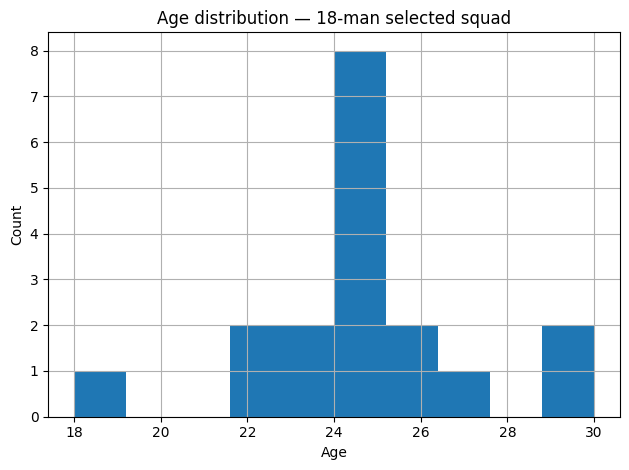

Saved: reports\figures\age_distribution_squad18.png


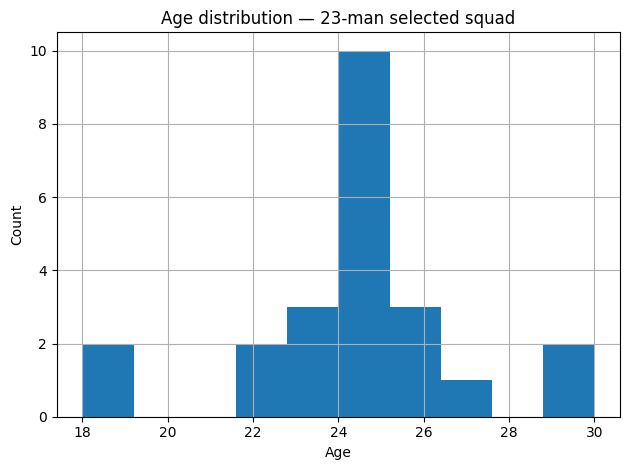

Saved: reports\figures\age_distribution_squad23.png


In [23]:
def plot_age_distribution(df: Optional[pd.DataFrame], title: str, out_name: str) -> None:
    if df is None or df.empty or "age" not in df.columns:
        print(f"[SKIP] {title} (missing data or age column)")
        return
    ages = pd.to_numeric(df["age"], errors="coerce").dropna()
    if ages.empty:
        print(f"[SKIP] {title} (no numeric ages)")
        return

    plt.figure()
    plt.hist(ages, bins=10)
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    out = FIG_DIR / out_name
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

plot_age_distribution(squad18, "Age distribution — 18-man selected squad", "age_distribution_squad18.png")
plot_age_distribution(squad23, "Age distribution — 23-man selected squad", "age_distribution_squad23.png")

## 8) (Optional) Enrichment: add player names from DB (if missing)

If exported CSVs lack player names, we can enrich from DuckDB if a suitable table exists.
We try `fact_player_season_fbref_tm` or the risk-adjusted universe.

In [24]:
con = connect_duckdb(DB_PATH)

name_map = None
for t in ["fact_player_season_fbref_tm", "risk_adjusted_universe_v2", "risk_adjusted_universe_v1"]:
    if table_exists(con, t):
        df_tmp = con.execute(f'''SELECT * FROM "{t}" LIMIT 1''').df()
        name_col = None
        for cand in ["player_name", "player"]:
            if cand in df_tmp.columns:
                name_col = cand
                break
        if name_col and "player_id" in df_tmp.columns:
            name_map = con.execute(f'''
                SELECT DISTINCT player_id, {name_col} AS player_name
                FROM "{t}"
                WHERE player_id IS NOT NULL AND {name_col} IS NOT NULL
            ''').df()
            break

if name_map is None:
    print("[INFO] Could not build name_map from DB. Skipping enrichment.")
else:
    print("Name map rows:", name_map.shape)
    if squad18 is not None and "player_name" not in squad18.columns and "player_id" in squad18.columns:
        squad18 = squad18.merge(name_map, on="player_id", how="left")
        print("Enriched squad18 with names.")

Name map rows: (1796, 2)
Enriched squad18 with names.


## 9) Executive Narrative (template)

### Executive Summary (Draft)

- Implemented a **budget-constrained decision layer** using **MILP** (HiGHS via SciPy) over risk-adjusted scouting signals.
- Model selects optimal **K-signings** under **TCO** constraints and supports scenario planning (tight / baseline / loose / risk-averse).
- Extended to **full squad construction** (18-man and 23-man) with **hard positional quotas**.
- Reporting layer exports **scenario tables**, **shortlists**, and **figures** into `reports/` for stakeholder review.

## 10) Outputs Checklist

After running this notebook, you should have:

- `reports/tables/scenario_summary_notebook05.csv`
- `reports/tables/shortlists_notebook05.csv`
- `reports/tables/squad_summary_notebook05.csv`
- `reports/figures/k_signings_objective_by_scenario.png`
- `reports/figures/k_signings_risk_talent_scenarios.png`
- `reports/figures/age_distribution_squad18.png`
- `reports/figures/age_distribution_squad23.png`